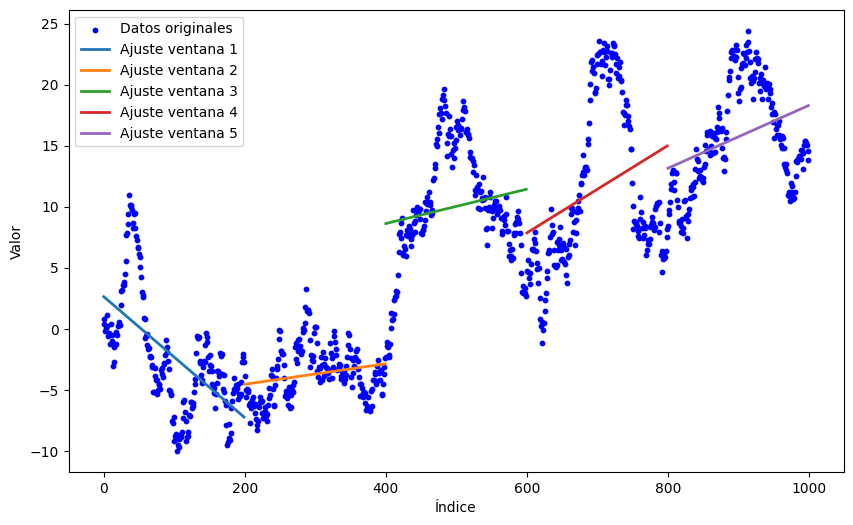

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

def ajustar_regresion_segmentada(data, num_ventanas, ax):
    n = len(data)
    x = np.arange(n)
    window_size = n // num_ventanas

    ax.scatter(x, data, label="Datos originales", color='blue', s=10)

    for i in range(0, n, window_size):
        end = i + window_size
        if end > n:
            end = n
        
        x_window = x[i:end].reshape(-1, 1)
        y_window = data[i:end]

        modelo = LinearRegression()
        modelo.fit(x_window, y_window)

        y_pred = modelo.predict(x_window)

        ax.plot(x_window, y_pred, label=f'Ajuste ventana {i//window_size + 1}', linewidth=2)

    ax.set_xlabel('Índice')
    ax.set_ylabel('Valor')
    ax.legend()

# Ejemplo de uso
data = np.random.randn(1000).cumsum()
fig, ax = plt.subplots(figsize=(10, 6))
ajustar_regresion_segmentada(data, num_ventanas=5, ax=ax)
plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# Definir una función para ajustar una regresión lineal en un número dado de ventanas
# y agregar líneas paralelas desplazadas en 'b' unidades
def ajustar_por_num_ventanas_con_paralelas(data, num_ventanas, b,ax):
    n = len(data)
    x = np.arange(n)
    
    # Calcular el tamaño de cada ventana
    window_size = n // num_ventanas
    
    # Preparar el gráfico
    plt.figure(figsize=(10, 6))
    ax.scatter(x, data, label="Datos originales", color='blue', s= 10)

    # Lista para almacenar los porcentajes de puntos dentro de las regiones
    porcentajes = []
    pendientes = []
    # Ajustar y graficar el ajuste lineal por cada ventana con las líneas paralelas
    for i in range(0, n, window_size):
        end = i + window_size
        if end > n:
            end = n
        
        x_window = x[i:end].reshape(-1, 1)
        y_window = data[i:end]
        
        # Crear y ajustar el modelo de regresión lineal
        modelo = LinearRegression()
        modelo.fit(x_window, y_window)
        
        # Obtener la pendiente y la intersección de la recta ajustada
        pendiente = modelo.coef_[0]
        interseccion = modelo.intercept_
        
        # Predecir valores ajustados
        y_pred = modelo.predict(x_window)
        
        # Graficar la recta ajustada para la ventana
        ax.plot(x_window, y_pred, label=f'Ajuste ventana {i//window_size + 1}', color='green')
        
        # Calcular las rectas paralelas desplazadas por 'b'
        y_paralela_superior = pendiente * x_window + (interseccion + b)
        y_paralela_inferior = pendiente * x_window + (interseccion - b)
        
        # Graficar las líneas paralelas
        ax.plot(x_window, y_paralela_superior, '--', color='red', label=f'Línea +b ventana {i//window_size + 1}')
        ax.plot(x_window, y_paralela_inferior, '--', color='red', label=f'Línea -b ventana {i//window_size + 1}')
        
        # Calcular el porcentaje de datos dentro de la región delimitada por las líneas paralelas
        dentro_region = np.sum((y_window >= y_paralela_inferior.flatten()) & (y_window <= y_paralela_superior.flatten()))
        fuera_region = len(y_window) - dentro_region
        
        # Calcular el porcentaje de datos dentro de la región respecto a los datos fuera de la región
        porcentaje = (dentro_region * 100)/(dentro_region + fuera_region)
        porcentajes.append(porcentaje)
        pendientes.append(pendiente)

    def indice_mayor_90(arr):
        n = len(arr)
    
        # Revisar cada índice para encontrar el primero que cumpla la condición
        for i in range(n): # np.all(np.array(pendientes)[i:] >= 0)
            if np.all(arr[i:] > 80) and len(arr[i:]) > 4:
                return i
        # Si no hay tal índice, regresar el último índice
        return n 
    indice = indice_mayor_90(np.array(porcentajes))*window_size
    ax.axvline(x= indice, color='red', linestyle='--', alpha=1)
    ax.set_xlabel('frecuencia k')
    ax.set_ylabel('Fases')
    return porcentajes

aratefacto_perfecto = np.angle(np.fft.rfft(x))
ara = [aratefacto_perfecto,aratefacto_perfecto]

fig, axes = plt.subplots(1, 2,figsize=(18, 9))  # 3 filas, 6 columnas, tamaño ajustado  figsize=(18, 9)

# Iterar sobre cada subplot y añadir datos
for array, ax in zip(ara,axes.flat):  # `axes.flat` para iterar en 1D
    # ax.set_yscale('log')
    porcentajes = ajustar_por_num_ventanas_con_paralelas(array, num_ventanas=25, b = 0.6,ax=ax)

# Ajustar los espacios entre subplots
plt.tight_layout()
plt.show()
